In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df= pd.read_excel('https://raw.github.com/ilhamluk/python-data-analys/main/dataset%20beverage.xlsx')
df

,Receipt_ID,Member_ID,Purchase_Date,Region,Store_City,Drink_Category,Drink_Name,Cups_Sold,Unit_Price,Promo_Pct,Sales_Value,Ingredient_Cost,Store_Type,Order_Channel,Customer_Age,Membership_Level,Complaint_Flag,Target_Sales
0,BEV-000001,MEM1007,Dec-09-2024,Yogyakarta,Jakrta,coffee,Drink_92,19,85.89,NaN,1631.91,1084.72,Restaurant,Take Away,38,Silver,NaN,133729
1,BEV-000002,MEM2356,2025-01-11,JKT,Surabaya,Soft Drink,Drink_9,5,757.68,0.20,3030.72,2806.87,Kiosk,Dine In,47,Silver,Y,247690
2,BEV-000003,MEM1713,May-03-2026,JKT,Surabaya,coffee,Drink_64,4,359.12,0.15,1221.01,895.56,Kiosk,Take Away,33,NaN,NaN,200363
3,BEV-000004,MEM3846,04/11/2024,JAKARTA,Sby,coffee,Drink_101,4,390.49,0.50,780.98,1010.34,Cafe,Dine In,64,gold,NaN,200399
4,BEV-000005,NaN,Sep-11-2024,Jogja,Jakrta,Tea,Drink_53,5,979.53,NaN,4897.65,4627.56,Restaurant,Delivery,32,Gold,NaN,105818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BEV-009996,MEM1004,2026-02-23,Yogyakarta,Jakarta,coffee,Drink_111,5,260.78,0.20,1043.12,1037.31,Cafe,Delivery,40,Silver,NaN,257337
9996,BEV-009997,MEM3294,Aug-31-2024,Surabaya,Bandung,Soft Drink,Drink_29,13,927.89,0.15,10253.18,9891.88,Restaurant,Take Away,57,Gold,N,72373
9997,BEV-009998,MEM2397,2025-06-04,Jogja,Jogja,coffee,Drink_113,11,256.15,0.00,2817.65,3251.89,Cafe,Delivery,24,Gold,NaN,283103
9998,BEV-009999,MEM1532,2024-08-26,Jakrta,Sby,Coffee,Drink_63,7,32.46,0.75,46.66,50.72,Kiosk,Take Away,68,gold,Y,299445


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Receipt_ID        10000 non-null  object 
 1   Member_ID         9413 non-null   object 
 2   Purchase_Date     10000 non-null  object 
 3   Region            10000 non-null  object 
 4   Store_City        10000 non-null  object 
 5   Drink_Category    10000 non-null  object 
 6   Drink_Name        10000 non-null  object 
 7   Cups_Sold         10000 non-null  int64  
 8   Unit_Price        10000 non-null  float64
 9   Promo_Pct         9237 non-null   float64
 10  Sales_Value       10000 non-null  float64
 11  Ingredient_Cost   10000 non-null  float64
 12  Store_Type        10000 non-null  object 
 13  Order_Channel     10000 non-null  object 
 14  Customer_Age      10000 non-null  int64  
 15  Membership_Level  8010 non-null   object 
 16  Complaint_Flag    6598 non-null   object 

In [ ]:
df.describe()

,Cups_Sold,Unit_Price,Promo_Pct,Sales_Value,Ingredient_Cost,Customer_Age,Target_Sales
count,10000.000000,10000.000000,9237.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,46.368300,1662.735210,0.335802,5.114571e+04,5.397535e+04,49.852300,153620.888100
std,347.554813,10702.102739,0.332272,2.096739e+06,2.566586e+06,74.371148,84406.823801
min,1.000000,10.210000,0.000000,6.100000e-01,3.200000e-01,5.000000,10001.000000
25%,5.000000,268.102500,0.050000,6.845450e+02,5.811125e+02,31.000000,80082.000000
50%,11.000000,518.530000,0.150000,2.350300e+03,2.035750e+03,44.000000,153215.000000
75%,16.000000,766.595000,0.750000,5.892985e+03,5.085610e+03,58.000000,227225.750000
max,4980.000000,148912.950000,0.950000,2.013678e+08,2.489208e+08,999.000000,299933.000000


In [ ]:
df.isnull().sum()

,0
Receipt_ID,0
Member_ID,587
Purchase_Date,0
Region,0
Store_City,0
Drink_Category,0
Drink_Name,0
Cups_Sold,0
Unit_Price,0
Promo_Pct,763


In [ ]:
df["Membership_Level"] = df["Membership_Level"].str.capitalize()
df["Membership_Level"] = df["Membership_Level"].fillna(
    df.groupby("Cups_Sold")["Membership_Level"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

In [ ]:
df['Member_ID'] = df['Member_ID'].fillna("Non-Member")

In [ ]:
df['Promo_Pct']=df['Promo_Pct'].fillna(0.0)

In [ ]:
df['Membership_Level'] = df['Membership_Level'].str.strip().str.title()

In [ ]:
df['Drink_Category'] = df['Drink_Category'].str.strip().str.title()

In [ ]:
df['Store_City'] = df['Store_City'].str.strip().str.title()

In [ ]:
hitung_modus = lambda x: x.mode()[0] if not x.mode().empty else 'N'
df['Complaint_Flag'] = df['Complaint_Flag'].fillna(
    df.groupby('Membership_Level')['Complaint_Flag'].transform(hitung_modus)
)
df['Complaint_Flag'] = df['Complaint_Flag'].str.upper()
df['Complaint_Flag'].isnull().sum()

np.int64(8)

In [ ]:
df['Complaint_Flag'].value_counts()

,count
Complaint_Flag,
Y,5384
N,4608


In [ ]:
df['Store_City'].unique()

array(['Jakrta', 'Surabaya', 'Sby', 'Bandng', 'Jogja', 'Bandung',
       'Yogyakarta', 'Jakarta'], dtype=object)

In [ ]:
df['Store_City'] = df['Store_City'].astype(str).str.strip()
df['Store_City'] = df['Store_City'].str.title()
kota = {
    'Jkt': 'Jakarta',
    'Jakrta': 'Jakarta',
    'Sby': 'Surabaya',
    'Jogja': 'Yogyakarta',
    'Bandng': 'Bandung'
}
df['Region'] = df['Store_City'].replace(kota)
df['Store_City'] = df['Store_City'].replace(kota)

In [ ]:
region_baru = {
    'Yogyakarta': 'DIY',
    'Bandung': 'Jawa Barat',
    'Jakarta': 'DKI Jakarta',
    'Surabaya': 'Jawa Timur'
}
df['Region'] = df['Store_City'].map(region_baru)

In [ ]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format="mixed")

In [ ]:
df

,Receipt_ID,Member_ID,Purchase_Date,Region,Store_City,Drink_Category,Drink_Name,Cups_Sold,Unit_Price,Promo_Pct,Sales_Value,Ingredient_Cost,Store_Type,Order_Channel,Customer_Age,Membership_Level,Complaint_Flag,Target_Sales
0,BEV-000001,MEM1007,2024-12-09,DKI Jakarta,Jakarta,Coffee,Drink_92,19,85.89,0.00,1631.91,1084.72,Restaurant,Take Away,38,Silver,N,133729
1,BEV-000002,MEM2356,2025-01-11,Jawa Timur,Surabaya,Soft Drink,Drink_9,5,757.68,0.20,3030.72,2806.87,Kiosk,Dine In,47,Silver,Y,247690
2,BEV-000003,MEM1713,2026-05-03,Jawa Timur,Surabaya,Coffee,Drink_64,4,359.12,0.15,1221.01,895.56,Kiosk,Take Away,33,Gold,Y,200363
3,BEV-000004,MEM3846,2024-04-11,Jawa Timur,Surabaya,Coffee,Drink_101,4,390.49,0.50,780.98,1010.34,Cafe,Dine In,64,Gold,Y,200399
4,BEV-000005,Non-Member,2024-09-11,DKI Jakarta,Jakarta,Tea,Drink_53,5,979.53,0.00,4897.65,4627.56,Restaurant,Delivery,32,Gold,Y,105818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BEV-009996,MEM1004,2026-02-23,DKI Jakarta,Jakarta,Coffee,Drink_111,5,260.78,0.20,1043.12,1037.31,Cafe,Delivery,40,Silver,N,257337
9996,BEV-009997,MEM3294,2024-08-31,Jawa Barat,Bandung,Soft Drink,Drink_29,13,927.89,0.15,10253.18,9891.88,Restaurant,Take Away,57,Gold,N,72373
9997,BEV-009998,MEM2397,2025-06-04,DIY,Yogyakarta,Coffee,Drink_113,11,256.15,0.00,2817.65,3251.89,Cafe,Delivery,24,Gold,Y,283103
9998,BEV-009999,MEM1532,2024-08-26,Jawa Timur,Surabaya,Coffee,Drink_63,7,32.46,0.75,46.66,50.72,Kiosk,Take Away,68,Gold,Y,299445


#Menambahkan Kolom Baru

In [ ]:
df['Gross_Profit'] = df['Sales_Value'] - df['Ingredient_Cost']


In [ ]:
df['Profit_Margin_Pct']=(df['Gross_Profit']/df['Sales_Value'])*100

In [ ]:
df['Is_Promo'] = (df['Promo_Pct'] > 0).astype(int)

In [ ]:
def tentukan_generasi(umur):
    if umur >= 14 and umur <= 29:
        return 'Gen Z'
    elif umur >= 30 and umur <= 45:
        return 'Millennial'
    elif umur >= 46 and umur <= 61:
        return 'Gen X'
    elif umur >= 62 and umur <= 80:
        return 'Boomer'
    else:
        return 'Lainnya'
df['Generasi'] = df['Customer_Age'].apply(tentukan_generasi)
df

,Receipt_ID,Member_ID,Purchase_Date,Region,Store_City,Drink_Category,Drink_Name,Cups_Sold,Unit_Price,Promo_Pct,...,Store_Type,Order_Channel,Customer_Age,Membership_Level,Complaint_Flag,Target_Sales,Gross_Profit,Profit_Margin_Pct,Is_Promo,Generasi
0,BEV-000001,MEM1007,2024-12-09,DKI Jakarta,Jakarta,Coffee,Drink_92,19,85.89,0.00,...,Restaurant,Take Away,38,Silver,N,133729,547.19,33.530648,0,Millennial
1,BEV-000002,MEM2356,2025-01-11,Jawa Timur,Surabaya,Soft Drink,Drink_9,5,757.68,0.20,...,Kiosk,Dine In,47,Silver,Y,247690,223.85,7.386034,1,Gen X
2,BEV-000003,MEM1713,2026-05-03,Jawa Timur,Surabaya,Coffee,Drink_64,4,359.12,0.15,...,Kiosk,Take Away,33,Gold,Y,200363,325.45,26.654163,1,Millennial
3,BEV-000004,MEM3846,2024-04-11,Jawa Timur,Surabaya,Coffee,Drink_101,4,390.49,0.50,...,Cafe,Dine In,64,Gold,Y,200399,-229.36,-29.368230,1,Boomer
4,BEV-000005,Non-Member,2024-09-11,DKI Jakarta,Jakarta,Tea,Drink_53,5,979.53,0.00,...,Restaurant,Delivery,32,Gold,Y,105818,270.09,5.514686,0,Millennial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BEV-009996,MEM1004,2026-02-23,DKI Jakarta,Jakarta,Coffee,Drink_111,5,260.78,0.20,...,Cafe,Delivery,40,Silver,N,257337,5.81,0.556983,1,Millennial
9996,BEV-009997,MEM3294,2024-08-31,Jawa Barat,Bandung,Soft Drink,Drink_29,13,927.89,0.15,...,Restaurant,Take Away,57,Gold,N,72373,361.30,3.523785,1,Gen X
9997,BEV-009998,MEM2397,2025-06-04,DIY,Yogyakarta,Coffee,Drink_113,11,256.15,0.00,...,Cafe,Delivery,24,Gold,Y,283103,-434.24,-15.411424,0,Gen Z
9998,BEV-009999,MEM1532,2024-08-26,Jawa Timur,Surabaya,Coffee,Drink_63,7,32.46,0.75,...,Kiosk,Take Away,68,Gold,Y,299445,-4.06,-8.701243,1,Boomer


In [ ]:
df['Is_Target_Achieved'] = df['Sales_Value'] >= df['Target_Sales']

In [ ]:
import numpy as np

df['Is_Target_Achieved'] = np.where(df['Sales_Value'] >= df['Target_Sales'], 1, 0)

In [ ]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format="mixed")

df['Purchase_Date'] = df['Purchase_Date'].apply(
    lambda x: x.replace(year=2025) if x.year == 2026 else x
)

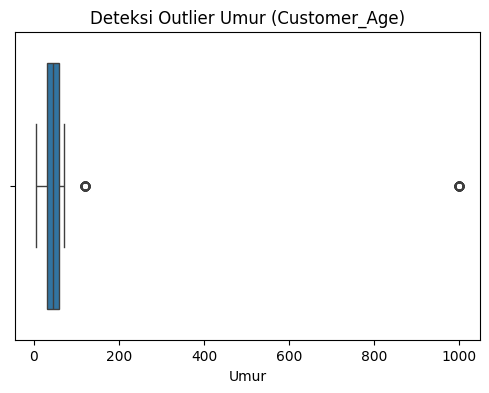

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Customer_Age"])
plt.title("Deteksi Outlier Umur (Customer_Age)")
plt.xlabel("Umur")
plt.show()

In [ ]:
Q1 = df["Customer_Age"].quantile(0.25)
Q3 = df["Customer_Age"].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

In [ ]:
outliers = df[
    (df["Customer_Age"] < batas_bawah) | (df["Customer_Age"] > batas_atas)
]

In [ ]:
if outliers.empty:
    print("Kesimpulan: Tidak ada data outlier pada kolom umur (Customer_Age).")
else:
    print("Data yang terdeteksi sebagai Outlier:")
    print(outliers[["Receipt_ID", "Customer_Age"]])

Data yang terdeteksi sebagai Outlier:
      Receipt_ID  Customer_Age
120   BEV-000121           120
186   BEV-000187           999
350   BEV-000351           120
418   BEV-000419           120
492   BEV-000493           120
...          ...           ...
9834  BEV-009835           120
9892  BEV-009893           120
9896  BEV-009897           999
9903  BEV-009904           120
9989  BEV-009990           120

[125 rows x 2 columns]


In [ ]:
jumlah_outlier = outliers.shape[0]
jumlah_outlier

125

In [ ]:
df["Customer_Age"].max()

999

In [ ]:
drop_outliers = df[
    (df["Customer_Age"] >= batas_bawah) & (df["Customer_Age"] <= batas_atas)
]

In [ ]:
df

,Receipt_ID,Member_ID,Purchase_Date,Region,Store_City,Drink_Category,Drink_Name,Cups_Sold,Unit_Price,Promo_Pct,...,Order_Channel,Customer_Age,Membership_Level,Complaint_Flag,Target_Sales,Gross_Profit,Profit_Margin_Pct,Is_Promo,Generasi,Is_Target_Achieved
0,BEV-000001,MEM1007,2024-12-09,DKI Jakarta,Jakarta,Coffee,Drink_92,19,85.89,0.00,...,Take Away,38,Silver,N,133729,547.19,33.530648,0,Millennial,0
1,BEV-000002,MEM2356,2025-01-11,Jawa Timur,Surabaya,Soft Drink,Drink_9,5,757.68,0.20,...,Dine In,47,Silver,Y,247690,223.85,7.386034,1,Gen X,0
2,BEV-000003,MEM1713,2025-05-03,Jawa Timur,Surabaya,Coffee,Drink_64,4,359.12,0.15,...,Take Away,33,Gold,Y,200363,325.45,26.654163,1,Millennial,0
3,BEV-000004,MEM3846,2024-04-11,Jawa Timur,Surabaya,Coffee,Drink_101,4,390.49,0.50,...,Dine In,64,Gold,Y,200399,-229.36,-29.368230,1,Boomer,0
4,BEV-000005,Non-Member,2024-09-11,DKI Jakarta,Jakarta,Tea,Drink_53,5,979.53,0.00,...,Delivery,32,Gold,Y,105818,270.09,5.514686,0,Millennial,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BEV-009996,MEM1004,2025-02-23,DKI Jakarta,Jakarta,Coffee,Drink_111,5,260.78,0.20,...,Delivery,40,Silver,N,257337,5.81,0.556983,1,Millennial,0
9996,BEV-009997,MEM3294,2024-08-31,Jawa Barat,Bandung,Soft Drink,Drink_29,13,927.89,0.15,...,Take Away,57,Gold,N,72373,361.30,3.523785,1,Gen X,0
9997,BEV-009998,MEM2397,2025-06-04,DIY,Yogyakarta,Coffee,Drink_113,11,256.15,0.00,...,Delivery,24,Gold,Y,283103,-434.24,-15.411424,0,Gen Z,0
9998,BEV-009999,MEM1532,2024-08-26,Jawa Timur,Surabaya,Coffee,Drink_63,7,32.46,0.75,...,Take Away,68,Gold,Y,299445,-4.06,-8.701243,1,Boomer,0


In [ ]:
if outliers.empty:
    print("Kesimpulan: Tidak ada data outlier pada kolom umur (Customer_Age).")
else:
    print("Data yang terdeteksi sebagai Outlier:")
    print(outliers[["Receipt_ID", "Customer_Age"]])

Data yang terdeteksi sebagai Outlier:
      Receipt_ID  Customer_Age
120   BEV-000121           120
186   BEV-000187           999
350   BEV-000351           120
418   BEV-000419           120
492   BEV-000493           120
...          ...           ...
9834  BEV-009835           120
9892  BEV-009893           120
9896  BEV-009897           999
9903  BEV-009904           120
9989  BEV-009990           120

[125 rows x 2 columns]


In [ ]:
df['Customer_Age'].unique()

array([ 38,  47,  33,  64,  32,  62,  25,  29,  66,  50,  52,  61,  36,
        37,  68,  55,  42,  53,  48,   5,  34,  40,  22,  26,  35,  58,
        41,  23,  56,  51,  44,  30,  67,  59,  49,  27,  54,  24,  63,
        28,  20,  19,  69,  57,  70,  65, 120,  39,  18,  43, 999,  60,
        31,  45,  46,  21])

In [ ]:
df["Membership_Level"] = df["Membership_Level"].str.capitalize()
df["Membership_Level"] = df["Membership_Level"].fillna(
    df.groupby("Cups_Sold")["Membership_Level"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

In [ ]:
df

,Receipt_ID,Member_ID,Purchase_Date,Region,Store_City,Drink_Category,Drink_Name,Cups_Sold,Unit_Price,Promo_Pct,...,Order_Channel,Customer_Age,Membership_Level,Complaint_Flag,Target_Sales,Gross_Profit,Profit_Margin_Pct,Is_Promo,Generasi,Is_Target_Achieved
0,BEV-000001,MEM1007,2024-12-09,DKI Jakarta,Jakarta,Coffee,Drink_92,19,85.89,0.00,...,Take Away,38,Silver,N,133729,547.19,33.530648,0,Millennial,0
1,BEV-000002,MEM2356,2025-01-11,Jawa Timur,Surabaya,Soft Drink,Drink_9,5,757.68,0.20,...,Dine In,47,Silver,Y,247690,223.85,7.386034,1,Gen X,0
2,BEV-000003,MEM1713,2025-05-03,Jawa Timur,Surabaya,Coffee,Drink_64,4,359.12,0.15,...,Take Away,33,Gold,Y,200363,325.45,26.654163,1,Millennial,0
3,BEV-000004,MEM3846,2024-04-11,Jawa Timur,Surabaya,Coffee,Drink_101,4,390.49,0.50,...,Dine In,64,Gold,Y,200399,-229.36,-29.368230,1,Boomer,0
4,BEV-000005,Non-Member,2024-09-11,DKI Jakarta,Jakarta,Tea,Drink_53,5,979.53,0.00,...,Delivery,32,Gold,Y,105818,270.09,5.514686,0,Millennial,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BEV-009996,MEM1004,2025-02-23,DKI Jakarta,Jakarta,Coffee,Drink_111,5,260.78,0.20,...,Delivery,40,Silver,N,257337,5.81,0.556983,1,Millennial,0
9996,BEV-009997,MEM3294,2024-08-31,Jawa Barat,Bandung,Soft Drink,Drink_29,13,927.89,0.15,...,Take Away,57,Gold,N,72373,361.30,3.523785,1,Gen X,0
9997,BEV-009998,MEM2397,2025-06-04,DIY,Yogyakarta,Coffee,Drink_113,11,256.15,0.00,...,Delivery,24,Gold,Y,283103,-434.24,-15.411424,0,Gen Z,0
9998,BEV-009999,MEM1532,2024-08-26,Jawa Timur,Surabaya,Coffee,Drink_63,7,32.46,0.75,...,Take Away,68,Gold,Y,299445,-4.06,-8.701243,1,Boomer,0


#Memindahkan Python ke postgres

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres.znknfjcxbkwvcbhoglhb"
password = quote_plus("MarKesot21*_")
host = "aws-1-ap-northeast-1.pooler.supabase.com"
port = "6543"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

In [ ]:
#df.to_sql("beverage",engine,if_exists="replace",index=False)